<a href="https://colab.research.google.com/github/fatuunreal/bengkelkoding/blob/3/A11_2022_14831_tgs_bk_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Menerapkan algoritma Decision Tree pada dataset adult.csv

#By : FATU RAHMAT
#NIM : A11.2022.14831

# 1. Import Library

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# 2. Load Dataset dan Define Nama Kolom

### Baca dataset

In [65]:
df = pd.read_csv('adult.csv', names=columns, na_values='?', skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Definisikan nama kolom sesuai deskripsi dataset

In [68]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 3. Cek Kualitas Data

### Cek missing values

In [69]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


### Cek duplikat

In [70]:
print("\nDuplikat Data:", df.duplicated().sum())


Duplikat Data: 24


### Distribusi target

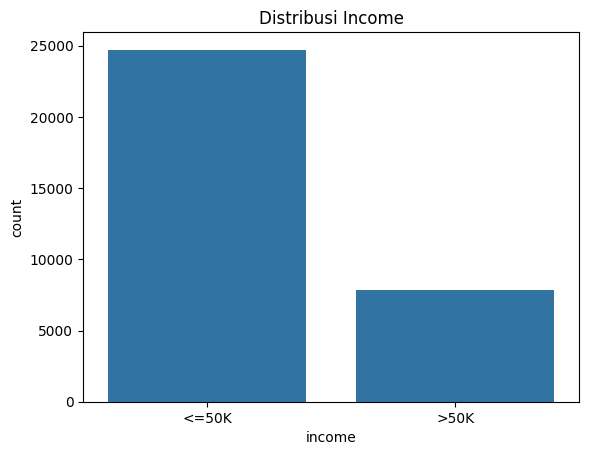

In [71]:
sns.countplot(x='income', data=df)
plt.title('Distribusi Income')
plt.show()

### Korelasi fitur numerik

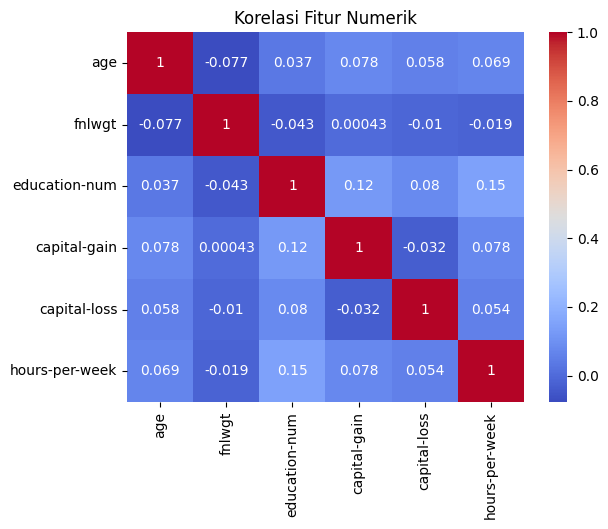

In [72]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

# 4. Penanganan Missing Values

### Hapus baris dengan missing values

In [73]:
df.dropna(inplace=True)

### Hapus kolom redundan

In [74]:
#kolom 'education-num' sudah mewakili dan memiliki fitur numerik
df.drop('education', axis=1, inplace=True)

### Hapus duplikat

In [75]:
df.drop_duplicates(inplace=True)

# 5. Analisis Outlier

### Visualisasi outlier untuk fitur numerik

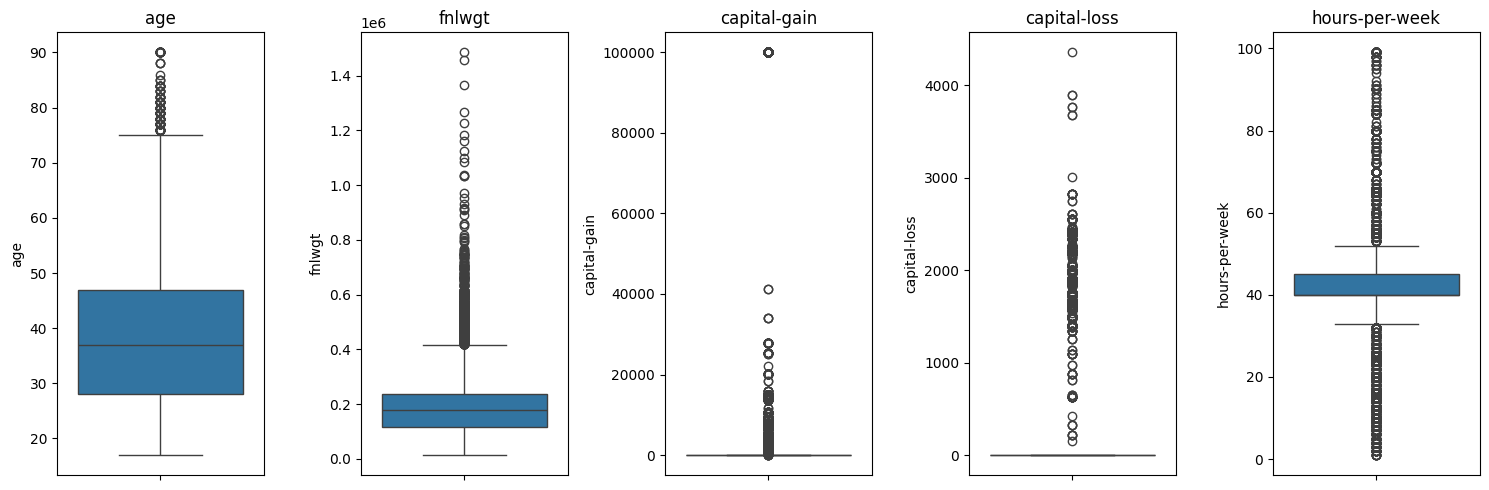

In [76]:
numerical_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

### Handling outlier dengan IQR untuk 'capital-gain' dan 'capital-loss'

In [77]:
Q1 = df[['capital-gain', 'capital-loss']].quantile(0.25)
Q3 = df[['capital-gain', 'capital-loss']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['capital-gain', 'capital-loss']] > (Q3 + 1.5 * IQR)).any(axis=1))]

# 6. Transformasi Data Kategorikal

### Encoding variabel target

In [78]:
df['income'] = LabelEncoder().fit_transform(df['income'])

### One-Hot Encoding untuk fitur kategorikal

In [79]:
categorical_cols = [
    'workclass', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X = df.drop('income', axis=1)
y = df['income']

# 7. Penanganan Class Imbalance dengan SMOTE

### Transformasi data

In [80]:
X_processed = preprocessor.fit_transform(X)

### Oversampling dengan SMOTE

In [81]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_processed, y)

# 8. Split Data dan Latih Model

### Split data

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

### Inisialisasi model Decision Tree

In [83]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

### Prediksi

In [84]:
y_pred = model.predict(X_test)

#9. Evaluasi Model

In [85]:
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi: 0.8673015873015874

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      6399
           1       0.85      0.88      0.87      6201

    accuracy                           0.87     12600
   macro avg       0.87      0.87      0.87     12600
weighted avg       0.87      0.87      0.87     12600



### Confusion Matrix

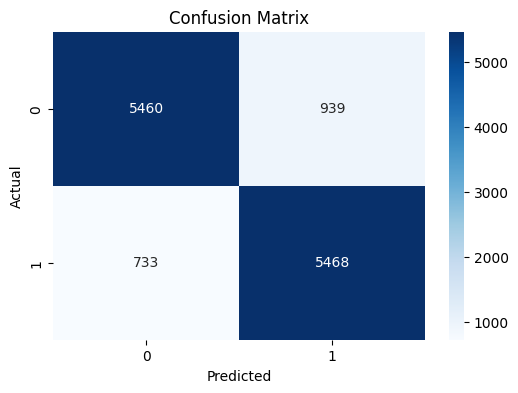

In [86]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Dokumentasi Preprocessing:**
## 1. **Penanganan Missing Values**: Baris dengan nilai hilang dihapus karena jumlahnya relatif kecil. Persentase nilai kosong relatif kecil (<5% dari total data), sehingga penghapusan tidak signifikan mengurangi ukuran dataset. Sehingga penghapusan missing value tepat dilakukan.
## 2. **Penghapusan Fitur Redundan** : kolom **education** dihapus karena sudah ada Kolom **education-num** sudah merepresentasikan tingkat pendidikan dalam bentuk numerik (misal: "Bachelors" = 13).
##3. **Penghapusan Duplikasi**: Duplikat dapat menyebabkan model overfitting karena data tertentu dihitung berulang kali, hal ini dilakukan guna meningkatkan generalisasi model.
##4. **Penanganan Outlier**: Outlier pada kolom capital-gain dan capital-loss diidentifikasi dan dihapus menggunakan metode IQR (Interquartile Range). Kedua kolom tersebut memiliki distribusi yang sangat miring (skewed) dengan nilai ekstrem. Outlier dapat mengganggu pembelahan (split) pada Decision Tree. Hal ini berguna untuk mencegah model terpengaruh oleh nilai ekstrem yang tidak representatif.
##5.**Transformasi Data Kategorikal**: Label Encoding untuk variabel target (income):<=50K → 0, >50K → 1.One-Hot Encoding untuk fitur kategorikal:
###Kolom: workclass, marital-status, occupation, relationship, race, sex, native-country.
###Contoh: Kolom workclass dengan nilai "Private", "Self-emp" diubah menjadi kolom biner seperti workclass_Private, workclass_Self-emp,
##6. **Penanganan Class Imbalance dengan SMOTE**: SMOTE (Synthetic Minority Oversampling Technique) digunakan untuk menyeimbangkan distribusi kelas target. Kelas <=50K (mayoritas) mendominasi dataset, sedangkan >50K (minoritas) hanya ~25%.Ketidakseimbangan dapat menyebabkan model bias ke kelas mayoritas. Hal ini guna meningkatkan kemampuan model untuk mengenali pola kelas minoritas.


